In [1]:
%pip install -q torch torchvision matplotlib pandas

In [2]:
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch:", torch.__version__)
print("Dispositivo:", device)

PyTorch: 2.11.0+cpu
Dispositivo: cpu


In [3]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Imágenes de entrenamiento:", len(train_dataset))
print("Imágenes de prueba:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 40.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.04MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.35MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.42MB/s]

Imágenes de entrenamiento: 60000
Imágenes de prueba: 10000


In [4]:
TASK_A = [0, 1, 2, 3, 4]
TASK_B = [5, 6, 7, 8, 9]

TRAIN_SAMPLES_PER_CLASS = 2000
BATCH_SIZE = 128

def extract_tensors(dataset, classes, max_per_class=None):
    targets = dataset.targets
    selected_indices = []

    for digit in classes:
        indices = torch.where(targets == digit)[0]

        if max_per_class is not None:
            indices = indices[:max_per_class]

        selected_indices.append(indices)

    indices = torch.cat(selected_indices)

    x = dataset.data[indices].float().unsqueeze(1) / 255.0
    y = dataset.targets[indices].long()

    return x, y


x_train_A, y_train_A = extract_tensors(
    train_dataset, TASK_A, TRAIN_SAMPLES_PER_CLASS
)

x_train_B, y_train_B = extract_tensors(
    train_dataset, TASK_B, TRAIN_SAMPLES_PER_CLASS
)

x_test_A, y_test_A = extract_tensors(test_dataset, TASK_A)
x_test_B, y_test_B = extract_tensors(test_dataset, TASK_B)

print("Tarea A:", x_train_A.shape, y_train_A.shape)
print("Tarea B:", x_train_B.shape, y_train_B.shape)
print("Prueba A:", x_test_A.shape)
print("Prueba B:", x_test_B.shape)

Tarea A: torch.Size([10000, 1, 28, 28]) torch.Size([10000])
Tarea B: torch.Size([10000, 1, 28, 28]) torch.Size([10000])
Prueba A: torch.Size([5139, 1, 28, 28])
Prueba B: torch.Size([4861, 1, 28, 28])


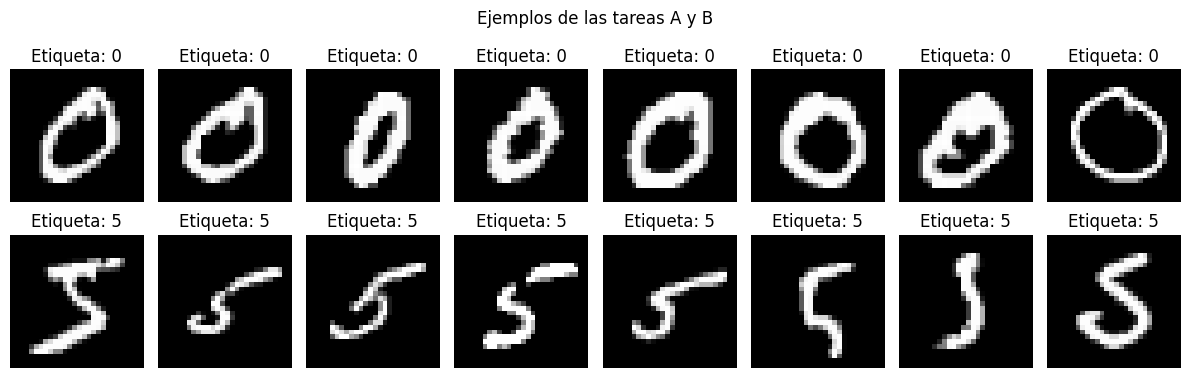

In [5]:
fig, axes = plt.subplots(2, 8, figsize=(12, 4))

for row, (images, labels) in enumerate([
    (x_train_A, y_train_A),
    (x_train_B, y_train_B)
]):
    for col in range(8):
        axes[row, col].imshow(
            images[col].squeeze(), cmap="gray"
        )
        axes[row, col].set_title(
            f"Etiqueta: {labels[col].item()}"
        )
        axes[row, col].axis("off")

plt.suptitle("Ejemplos de las tareas A y B")
plt.tight_layout()
plt.show()

In [6]:
class DigitCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def create_model():
    return DigitCNN().to(device)


# Guardamos un estado inicial común para los tres métodos.
torch.manual_seed(SEED)
initial_model = create_model()
INITIAL_STATE = copy.deepcopy(initial_model.state_dict())

print(initial_model)

DigitCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [7]:
def make_loader(x, y, shuffle=True):
    dataset = TensorDataset(x, y)

    generator = torch.Generator()
    generator.manual_seed(SEED)

    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        generator=generator if shuffle else None,
        num_workers=0
    )


def evaluate(model, x, y):
    model.eval()

    loader = make_loader(x, y, shuffle=False)
    correct = 0
    total = 0
    total_loss = 0.0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = F.cross_entropy(logits, labels)

            total_loss += loss.item() * labels.size(0)
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

    return {
        "accuracy": 100.0 * correct / total,
        "loss": total_loss / total
    }


def train_model(
    model,
    x,
    y,
    epochs=3,
    lr=1e-3,
    batch_size=BATCH_SIZE,
    extra_loss_fn=None
):
    loader = make_loader(x, y, shuffle=True)

    optimizer = torch.optim.Adam(
        model.parameters(), lr=lr
    )

    history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        total = 0

        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            logits = model(images)
            loss = F.cross_entropy(logits, labels)

            if extra_loss_fn is not None:
                loss = loss + extra_loss_fn()

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            total += labels.size(0)

        epoch_loss = running_loss / total
        history.append(epoch_loss)

        print(
            f"Época {epoch + 1}/{epochs} "
            f"- pérdida: {epoch_loss:.4f}"
        )

    return history

In [8]:
EPOCHS = 3
LEARNING_RATE = 1e-3

def new_model():
    model = create_model()
    model.load_state_dict(copy.deepcopy(INITIAL_STATE))
    return model


naive_model = new_model()

# Estado inicial: antes de aprender ninguna tarea.
naive_initial_A = evaluate(naive_model, x_test_A, y_test_A)
naive_initial_B = evaluate(naive_model, x_test_B, y_test_B)

print("Antes de entrenar:")
print("Tarea A:", naive_initial_A["accuracy"])
print("Tarea B:", naive_initial_B["accuracy"])

# Primera fase: aprender dígitos 0-4.
print("\nEntrenamiento de la tarea A")
train_model(
    naive_model,
    x_train_A,
    y_train_A,
    epochs=EPOCHS,
    lr=LEARNING_RATE
)

naive_after_A = {
    "A": evaluate(naive_model, x_test_A, y_test_A),
    "B": evaluate(naive_model, x_test_B, y_test_B)
}

# Segunda fase: aprender dígitos 5-9, sin datos de A.
print("\nEntrenamiento de la tarea B")
train_model(
    naive_model,
    x_train_B,
    y_train_B,
    epochs=EPOCHS,
    lr=LEARNING_RATE
)

naive_after_B = {
    "A": evaluate(naive_model, x_test_A, y_test_A),
    "B": evaluate(naive_model, x_test_B, y_test_B)
}

print("\nDespués de la tarea A:")
print("Precisión A:", naive_after_A["A"]["accuracy"])
print("Precisión B:", naive_after_A["B"]["accuracy"])

print("\nDespués de la tarea B:")
print("Precisión A:", naive_after_B["A"]["accuracy"])
print("Precisión B:", naive_after_B["B"]["accuracy"])

Antes de entrenar:
Tarea A: 0.7394434714925082
Tarea B: 19.461016251800043

Entrenamiento de la tarea A
Época 1/3 - pérdida: 0.6457
Época 2/3 - pérdida: 0.1384
Época 3/3 - pérdida: 0.0946

Entrenamiento de la tarea B
Época 1/3 - pérdida: 2.2035
Época 2/3 - pérdida: 0.2703
Época 3/3 - pérdida: 0.1662

Después de la tarea A:
Precisión A: 98.52111305701499
Precisión B: 0.0

Después de la tarea B:
Precisión A: 0.0
Precisión B: 95.47418226702325


In [9]:
def create_replay_memory(x, y, samples_per_class=400):
    selected = []

    for digit in TASK_A:
        indices = torch.where(y == digit)[0]

        # Selección reproducible de ejemplos de cada clase.
        generator = torch.Generator().manual_seed(SEED + digit)
        permutation = torch.randperm(
            len(indices), generator=generator
        )

        chosen = indices[permutation[:samples_per_class]]
        selected.append(chosen)

    selected = torch.cat(selected)

    return x[selected].clone(), y[selected].clone()


memory_x, memory_y = create_replay_memory(
    x_train_A,
    y_train_A,
    samples_per_class=400
)

print("Ejemplos guardados:", len(memory_y))
print("Clases en la memoria:", torch.unique(memory_y).tolist())

Ejemplos guardados: 2000
Clases en la memoria: [0, 1, 2, 3, 4]


In [10]:
replay_model = new_model()

print("Entrenamiento inicial de A")
train_model(
    replay_model,
    x_train_A,
    y_train_A,
    epochs=EPOCHS,
    lr=LEARNING_RATE
)

replay_after_A = {
    "A": evaluate(replay_model, x_test_A, y_test_A),
    "B": evaluate(replay_model, x_test_B, y_test_B)
}

# Mezclamos los datos nuevos con la memoria de A.
replay_train_x = torch.cat([x_train_B, memory_x], dim=0)
replay_train_y = torch.cat([y_train_B, memory_y], dim=0)

print("\nEntrenamiento de B con Experience Replay")
train_model(
    replay_model,
    replay_train_x,
    replay_train_y,
    epochs=EPOCHS,
    lr=LEARNING_RATE
)

replay_after_B = {
    "A": evaluate(replay_model, x_test_A, y_test_A),
    "B": evaluate(replay_model, x_test_B, y_test_B)
}

print("\nResultados finales de Replay")
print("Precisión A:", replay_after_B["A"]["accuracy"])
print("Precisión B:", replay_after_B["B"]["accuracy"])

Entrenamiento inicial de A
Época 1/3 - pérdida: 0.6457
Época 2/3 - pérdida: 0.1384
Época 3/3 - pérdida: 0.0946

Entrenamiento de B con Experience Replay
Época 1/3 - pérdida: 1.8663
Época 2/3 - pérdida: 0.2983
Época 3/3 - pérdida: 0.1994

Resultados finales de Replay
Precisión A: 89.80346370889278
Precisión B: 96.21477062332853


In [46]:
def estimate_fisher(model, x, y, max_samples=1000):
    model.eval()

    fisher = {
        name: torch.zeros_like(param)
        for name, param in model.named_parameters()
        if param.requires_grad
    }

    n = min(max_samples, len(y))
    indices = torch.randperm(len(y))[:n]

    for idx in indices:
        model.zero_grad(set_to_none=True)

        image = x[idx:idx + 1].to(device)
        label = y[idx:idx + 1].to(device)

        logits = model(image)
        log_probs = F.log_softmax(logits, dim=1)
        log_likelihood = log_probs[0, label.item()]

        log_likelihood.backward()

        for name, param in model.named_parameters():
            if param.requires_grad and param.grad is not None:
                fisher[name] += param.grad.detach().pow(2)

    for name in fisher:
        fisher[name] /= n

    return fisher

In [47]:
ewc_model = new_model()

print("Entrenamiento de A")
train_model(
    ewc_model,
    x_train_A,
    y_train_A,
    epochs=EPOCHS,
    lr=LEARNING_RATE
)

ewc_after_A = {
    "A": evaluate(ewc_model, x_test_A, y_test_A),
    "B": evaluate(ewc_model, x_test_B, y_test_B)
}

old_params = {
    name: param.detach().clone()
    for name, param in ewc_model.named_parameters()
    if param.requires_grad
}

print("\nEstimando matriz de Fisher...")
fisher = estimate_fisher(
    ewc_model,
    x_train_A,
    y_train_A,
    max_samples=1000
)

fisher_values = torch.cat([
    values.detach().flatten()
    for values in fisher.values()
])

print("Media de Fisher:", fisher_values.mean().item())
print("Máximo de Fisher:", fisher_values.max().item())
print("Valores mayores que cero:", (fisher_values > 0).sum().item())
print("Total de valores:", fisher_values.numel())

ewc_model.eval()

with torch.no_grad():
    logits = ewc_model(x_train_B[:512].to(device))
    loss_B = F.cross_entropy(
        logits,
        y_train_B[:512].to(device)
    )

EWC_LAMBDA = 15000.0

def ewc_penalty():
    penalty = torch.zeros((), device=device)

    for name, param in ewc_model.named_parameters():
        if param.requires_grad:
            penalty += (
                fisher[name] *
                (param - old_params[name]).pow(2)
            ).sum()

    return (EWC_LAMBDA / 2) * penalty

def inspect_ewc():
    weighted_change = 0.0
    total_change = 0.0

    for name, param in ewc_model.named_parameters():
        if param.requires_grad:
            delta = param.detach() - old_params[name]

            weighted_change += (
                fisher[name] * delta.pow(2)
            ).sum().item()

            total_change += delta.pow(2).sum().item()

    print(f"Cambio ponderado por Fisher: {weighted_change:.8f}")
    print(f"Cambio total de parámetros: {total_change:.8f}")
    print(f"Penalización EWC: {ewc_penalty().item():.8f}")

penalty = ewc_penalty()

print(f"Pérdida de clasificación B: {loss_B.item():.6f}")
print(f"Penalización EWC: {penalty.item():.6f}")
print(f"Lambda: {EWC_LAMBDA}")

print("\nEntrenamiento de B con EWC")
train_model(
    ewc_model,
    x_train_B,
    y_train_B,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    extra_loss_fn=ewc_penalty
)

ewc_after_B = {
    "A": evaluate(ewc_model, x_test_A, y_test_A),
    "B": evaluate(ewc_model, x_test_B, y_test_B)
}

print("\nResultados finales de EWC")
print("Precisión A:", ewc_after_A["A"]["accuracy"])
print("Precisión B:", ewc_after_B["B"]["accuracy"])

inspect_ewc()

Entrenamiento de A
Época 1/3 - pérdida: 0.6457
Época 2/3 - pérdida: 0.1384
Época 3/3 - pérdida: 0.0946

Estimando matriz de Fisher...
Media de Fisher: 0.0005507891764864326
Máximo de Fisher: 3.0301215648651123
Valores mayores que cero: 90951
Total de valores: 206922
Pérdida de clasificación B: 21.085169
Penalización EWC: 0.000000
Lambda: 15000.0

Entrenamiento de B con EWC
Época 1/3 - pérdida: 4.5376
Época 2/3 - pérdida: 0.7897
Época 3/3 - pérdida: 0.5221

Resultados finales de EWC
Precisión A: 98.52111305701499
Precisión B: 89.5700473153672
Cambio ponderado por Fisher: 0.00001064
Cambio total de parámetros: 36.10199001
Penalización EWC: 0.07980221


In [49]:
results = {
    "Naive": {
        "A_antes_B": naive_after_A["A"]["accuracy"],
        "B_antes_B": naive_after_A["B"]["accuracy"],
        "A_despues_B": naive_after_B["A"]["accuracy"],
        "B_despues_B": naive_after_B["B"]["accuracy"],
    },
    "Experience Replay": {
        "A_antes_B": replay_after_A["A"]["accuracy"],
        "B_antes_B": replay_after_A["B"]["accuracy"],
        "A_despues_B": replay_after_B["A"]["accuracy"],
        "B_despues_B": replay_after_B["B"]["accuracy"],
    },
    "EWC": {
        "A_antes_B": ewc_after_A["A"]["accuracy"],
        "B_antes_B": ewc_after_A["B"]["accuracy"],
        "A_despues_B": ewc_after_B["A"]["accuracy"],
        "B_despues_B": ewc_after_B["B"]["accuracy"],
    },
}

df = pd.DataFrame(results).T

df["Olvido_A_pp"] = (
    df["A_antes_B"] - df["A_despues_B"]
)

df["Cambio_B_pp"] = (
    df["B_despues_B"] - df["B_antes_B"]
)

df["Precision_promedio_final"] = (
    df["A_despues_B"] + df["B_despues_B"]
) / 2

df = df.round(2)

print("Resultados de aprendizaje continuo:")
display(df)

Resultados de aprendizaje continuo:


,A_antes_B,B_antes_B,A_despues_B,B_despues_B,Olvido_A_pp,Cambio_B_pp,Precision_promedio_final
Naive,98.52,0.0,0.00,95.47,98.52,95.47,47.74
Experience Replay,98.52,0.0,89.80,96.21,8.72,96.21,93.01
EWC,98.52,0.0,9.61,89.57,88.91,89.57,49.59


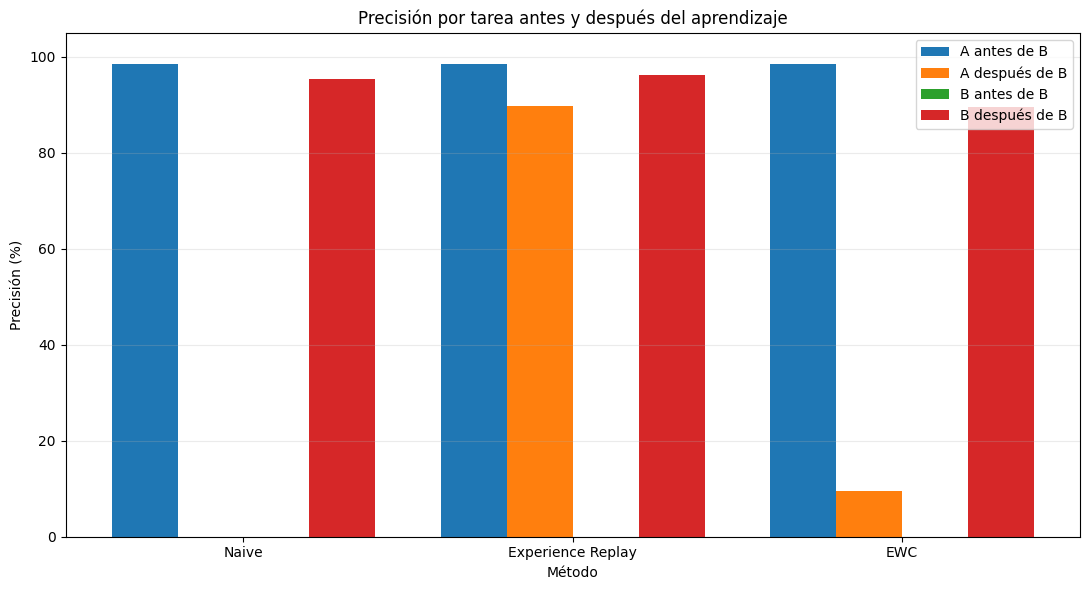

In [50]:
methods = df.index.tolist()
x = np.arange(len(methods))
width = 0.2

fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(
    x - 1.5 * width,
    df["A_antes_B"],
    width,
    label="A antes de B"
)

ax.bar(
    x - 0.5 * width,
    df["A_despues_B"],
    width,
    label="A después de B"
)

ax.bar(
    x + 0.5 * width,
    df["B_antes_B"],
    width,
    label="B antes de B"
)

ax.bar(
    x + 1.5 * width,
    df["B_despues_B"],
    width,
    label="B después de B"
)

ax.set_ylabel("Precisión (%)")
ax.set_xlabel("Método")
ax.set_title("Precisión por tarea antes y después del aprendizaje")
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylim(0, 105)
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


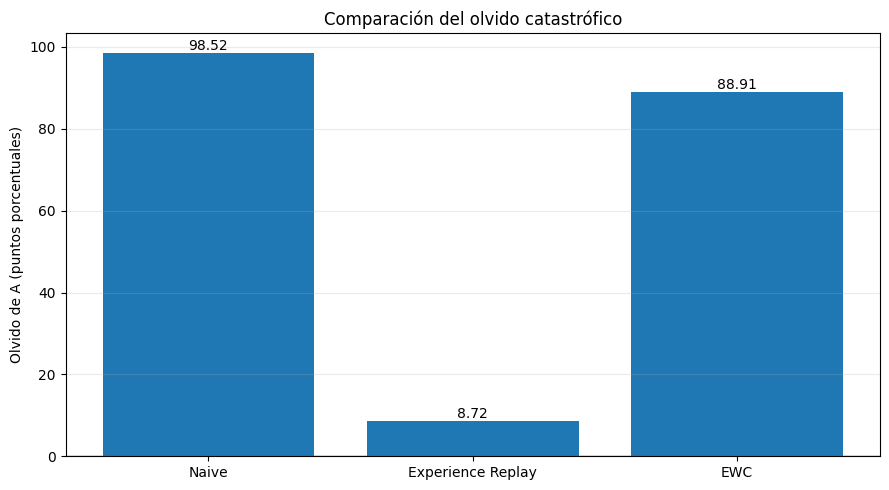

In [51]:
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    df.index,
    df["Olvido_A_pp"]
)

ax.axhline(0, linewidth=1)
ax.set_ylabel("Olvido de A (puntos porcentuales)")
ax.set_title("Comparación del olvido catastrófico")
ax.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, df["Olvido_A_pp"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom" if value >= 0 else "top"
    )

plt.tight_layout()
plt.show()

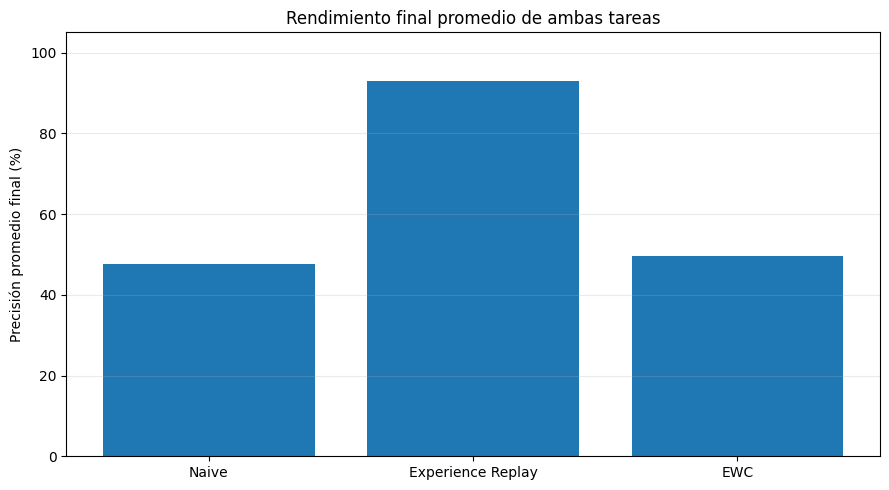

In [52]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    df.index,
    df["Precision_promedio_final"]
)

ax.set_ylabel("Precisión promedio final (%)")
ax.set_title("Rendimiento final promedio de ambas tareas")
ax.set_ylim(0, 105)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

In [53]:
initial_A = naive_initial_A["accuracy"]
initial_B = naive_initial_B["accuracy"]

evolution = pd.DataFrame([
    {
        "Método": "Naive",
        "A_inicial": initial_A,
        "B_inicial": initial_B,
        "A_despues_A": naive_after_A["A"]["accuracy"],
        "B_despues_A": naive_after_A["B"]["accuracy"],
        "A_despues_B": naive_after_B["A"]["accuracy"],
        "B_despues_B": naive_after_B["B"]["accuracy"],
    },
    {
        "Método": "Experience Replay",
        "A_inicial": initial_A,
        "B_inicial": initial_B,
        "A_despues_A": replay_after_A["A"]["accuracy"],
        "B_despues_A": replay_after_A["B"]["accuracy"],
        "A_despues_B": replay_after_B["A"]["accuracy"],
        "B_despues_B": replay_after_B["B"]["accuracy"],
    },
    {
        "Método": "EWC",
        "A_inicial": initial_A,
        "B_inicial": initial_B,
        "A_despues_A": ewc_after_A["A"]["accuracy"],
        "B_despues_A": ewc_after_A["B"]["accuracy"],
        "A_despues_B": ewc_after_B["A"]["accuracy"],
        "B_despues_B": ewc_after_B["B"]["accuracy"],
    }
])

evolution = evolution.set_index("Método").round(2)
display(evolution)

,A_inicial,B_inicial,A_despues_A,B_despues_A,A_despues_B,B_despues_B
Método,,,,,,
Naive,0.74,19.46,98.52,0.0,0.00,95.47
Experience Replay,0.74,19.46,98.52,0.0,89.80,96.21
EWC,0.74,19.46,98.52,0.0,9.61,89.57


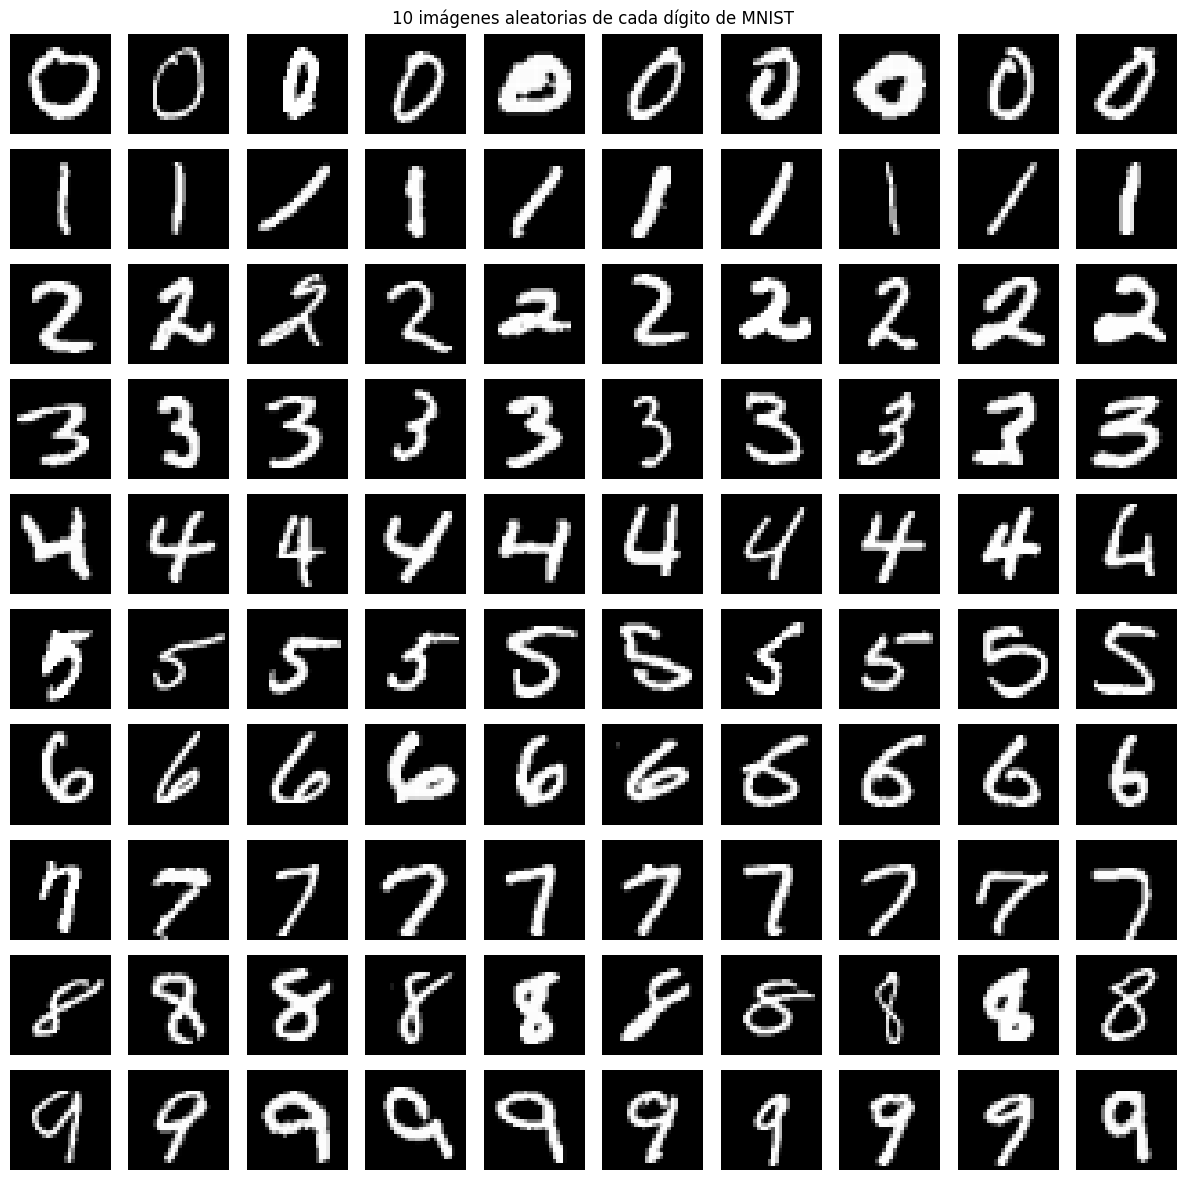

In [43]:
x_train = torch.cat([x_train_A, x_train_B], dim=0)
y_train = torch.cat([y_train_A, y_train_B], dim=0)

import matplotlib.pyplot as plt
import torch

fig, axes = plt.subplots(10, 10, figsize=(12, 12))

for digito in range(10):
    # Encontrar todas las imágenes correspondientes al dígito
    indices = torch.where(y_train == digito)[0]

    # Seleccionar 10 índices aleatorios sin repetir
    indices_aleatorios = indices[
        torch.randperm(len(indices))[:10]
    ]

    for columna, idx in enumerate(indices_aleatorios):
        imagen = x_train[idx].squeeze().cpu().numpy()

        axes[digito, columna].imshow(imagen, cmap="gray")
        axes[digito, columna].axis("off")

        if columna == 0:
            axes[digito, columna].set_ylabel(
                f"Dígito {digito}", fontsize=10
            )

plt.suptitle("10 imágenes aleatorias de cada dígito de MNIST")
plt.tight_layout()
plt.show()